In [11]:
#cell 1
# import numpy as np
import matplotlib.pyplot as plt

# ---- PCA FEATURE EXTRACTION (COPIED FROM NOTEBOOK 1) ----
from sklearn.decomposition import PCA

def pca_features(dataset_4d, n_components=10, seed=0, normalise=True):
    
    ny, nx, dy, dx = dataset_4d.shape
    
    X = dataset_4d.reshape(ny * nx, dy * dx).astype(np.float32)

    if normalise:
        X = X / (X.sum(axis=1, keepdims=True) + 1e-12)

    pca = PCA(n_components=n_components, random_state=seed)

    Xp = pca.fit_transform(X)

    return Xp, (ny, nx)
#################################################################

# ---- POISSON NOISE MODEL (copied from Notebook 1) ----
def add_poisson_noise_4d(data4d, dose, seed=0, bg_frac=0.02):

    rng = np.random.default_rng(seed)

    ny, nx, dy, dx = data4d.shape
    out = np.empty_like(data4d, dtype=np.float32)

    for i in range(ny):
        for j in range(nx):

            dp = np.clip(data4d[i, j], 0, None).astype(np.float32)

            prob_sig = dp / (dp.sum() + 1e-12)

            prob_bg = np.ones_like(dp, dtype=np.float32)
            prob_bg /= prob_bg.sum()

            prob = (1 - bg_frac) * prob_sig + bg_frac * prob_bg

            lam = prob * float(dose)

            counts = rng.poisson(lam).astype(np.float32)

            out[i, j] = counts / (float(dose) + 1e-12)

    return out
###################################################################################
import hyperspy.api as hs
import pyxem as pxm
import diffpy.structure #lib for cif file handling
from tempfile import TemporaryFile
#from diffsims.libraries.structure_library import StructureLibrary #to store crystal structures and orientations
from diffsims.generators.diffraction_generator import DiffractionGenerator #simulates electron diffractn patterns
#from diffsims.generators.library_generator import DiffractionLibraryGenerator, VectorLibraryGenerator #for dps
#import random

# Load your structure
# Ensure the path matches your local machine
cif_path = r"C:\Users\annam\Downloads\Y6_NatCommun.cif"
y6 = diffpy.structure.loadStructure(cif_path)

print("Structure loaded successfully.")

Structure loaded successfully.


Simulating 400 orientations at 300.0kV...
First 10 Euler Angles (Alpha, Beta, Gamma):
 0: [  0.           4.05226794 291.24611797]
 1: [  0.           7.02166442 153.73835392]
 2: [ 0.          9.06872155 16.23058987]
 3: [  0.          10.73475267 238.72282582]
 4: [  0.          12.17717567 101.21506177]
 5: [  0.          13.46803671 323.70729772]
 6: [  0.          14.64746931 186.19953367]
 7: [ 0.         15.74054853 48.69176962]
 8: [  0.          16.76418128 271.18400557]
 9: [  0.          17.73040626 133.67624152]
Progress: 0/400
Progress: 50/400
Progress: 100/400
Progress: 150/400
Progress: 200/400
Progress: 250/400
Progress: 300/400
Progress: 350/400
Data Generation Complete.


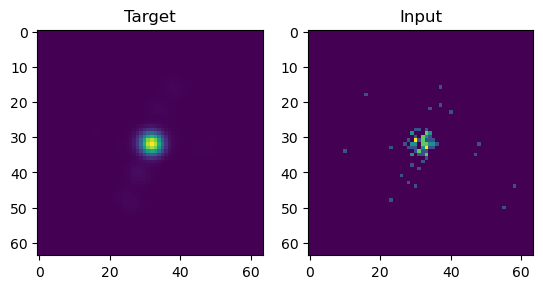

In [12]:
# --- CELL 2: PHYSICS & DATA GENERATION ENGINE ---
import numpy as np
import matplotlib.pyplot as plt
from diffsims.generators.diffraction_generator import DiffractionGenerator

# --- CONFIGURATION ---
BEAM_ENERGY = 300.0  
N_TRAIN = 400
IMG_DIM = 64         
TRAIN_DOSE = 100     
SCALE = 0.032
REC_RAD = SCALE * (IMG_DIM // 2)
#make sure conditions for y6 are matched
#256 in diffraction pattern size the dps should individually the same here 300 copies of 256 by 256

# Re-init generator
diff_gen = DiffractionGenerator(
    accelerating_voltage=BEAM_ENERGY, 
    scattering_params="xtables",
    minimum_intensity=1e-5
)

def simulate_dp(euler_angles, shape=(64, 64), sigma=2): #256 by 256 for consistency 
    """The core simulation function"""
    sim_i = diff_gen.calculate_ed_data(
        y6,
        reciprocal_radius=REC_RAD,
        rotation=euler_angles,
        with_direct_beam=True,
        max_excitation_error=0.02,
    )
    sim_i.calibration = SCALE
    return sim_i.get_diffraction_pattern(shape=shape, sigma=sigma).astype(np.float32)




def add_poisson_noise(dataset, dose, seed=0, bg_frac=0.0):
    """
    Adds Poisson noise to either a single DP or a 4D dataset.
    """
    rng = np.random.default_rng(seed)
    # Scale clean patterns by the target dose
    noisy = dataset * dose + (bg_frac * dose)
    # Apply Poisson sampling
    noisy = rng.poisson(noisy).astype(np.float32)
    # Normalize back
    return noisy / (dose + 1e-12)

def add_poisson_dae(dp, dose, rng):
    """Keep this for your Cell 9 loop compatibility"""
    dp_clipped = np.clip(dp, 0, None)
    prob = dp_clipped / (dp_clipped.sum() + 1e-12)
    lam = prob * float(dose)
    counts = rng.poisson(lam=lam).astype(np.float32)
    return counts / (float(dose) + 1e-12)

def get_uniform_euler(n):
    """Generates uniform points on a sphere to avoid 'pole clustering'"""
    indices = np.arange(0, n, dtype=float) + 0.5
    phi = np.arccos(1 - 2*indices/n)
    theta = np.pi * (1 + 5**0.5) * indices
    return np.stack([np.zeros(n), np.rad2deg(phi), np.rad2deg(theta % (2*np.pi))], axis=1)
# --- GENERATE DATA ---
x_train_clean = []
x_train_noisy = []
eulers = get_uniform_euler(N_TRAIN)
rng = np.random.default_rng(seed=42)

print(f"Simulating {N_TRAIN} orientations at {BEAM_ENERGY}kV...")

# --- ADD THIS LINE TO PRINT THE FIRST 10 ---
print("First 10 Euler Angles (Alpha, Beta, Gamma):")
for i in range(10): print(f" {i}: {eulers[i]}")

for i in range(N_TRAIN):
    if i % 50 == 0: print(f"Progress: {i}/{N_TRAIN}")
    
    # 1. Clean Target
    clean = simulate_dp(tuple(eulers[i]), shape=(IMG_DIM, IMG_DIM)) 
    
    # 2. Noisy Input
    noisy = add_poisson_dae(clean, dose=TRAIN_DOSE, rng=rng)
    
    x_train_clean.append(clean)
    x_train_noisy.append(noisy)

# Format for TensorFlow (Samples, Width, Height, Channels)
x_train_clean = np.expand_dims(np.array(x_train_clean), -1)
x_train_noisy = np.expand_dims(np.array(x_train_noisy), -1)

print("Data Generation Complete.")

# Visual verification
plt.subplot(1,2,1); plt.imshow(x_train_clean[0,...,0]); plt.title("Target")
plt.subplot(1,2,2); plt.imshow(x_train_noisy[0,...,0]); plt.title("Input")
plt.show()

In [13]:
'''"ClusteringDemo (1).ipynb"
import tensorflow as tf
from tensorflow.keras import layers, models

def build_vae():
    # Input: 64x64 grayscale images
    input_img = layers.Input(shape=(64, 64, 1))

    # --- ENCODER ---
    # Downsamples to 32x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Downsamples to 16x16
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # --- BOTTLENECK ---
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # --- DECODER ---
    # Upsamples back to 32x32
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    # Upsamples back to 64x64
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    # Output layer: uses 'sigmoid' to keep values between 0 and 1
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder

# Build the model
vae_model = build_vae()
vae_model.summary()
'''

# --- REVISED CELL 4: DAE ARCHITECTURE ---
import tensorflow as tf
from tensorflow.keras import layers, models

def build_dae_fixed():
    # Input shape (64, 64, 1)
    input_img = layers.Input(shape=(64, 64, 1))

    # --- ENCODER ---
    # Downsample to 32x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Downsample to 16x16
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    # --- BOTTLENECK ---
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # --- DECODER ---
    # Upsample to 32x32
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    # Upsample to 64x64
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    # FINAL LAYER: Use 'linear' to prevent the "black box" output
    decoded = layers.Conv2D(1, (3, 3), activation='linear', padding='same')(x)

    model = models.Model(input_img, decoded)
    
    # Using Adam optimizer with a standard learning rate
    model.compile(optimizer='adam', loss='mse')
    
    return model

# Initialize the new model
dae_model = build_dae_fixed()
dae_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

Starting DAE Training...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 7.3255e-04 - val_loss: 2.8757e-04
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 2.4379e-04 - val_loss: 1.3957e-04
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 1.6385e-04 - val_loss: 9.4326e-05
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 1.0213e-04 - val_loss: 7.6244e-05
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 6.9919e-05 - val_loss: 6.0620e-05
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 5.8801e-05 - val_loss: 5.8370e-05
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 4.7315e-05 - val_loss: 4.2784e-05
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 3.6265e-05 - val_loss: 3.4384e-05
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 2.5617e-05 - val_loss: 3.1604e-05
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step 

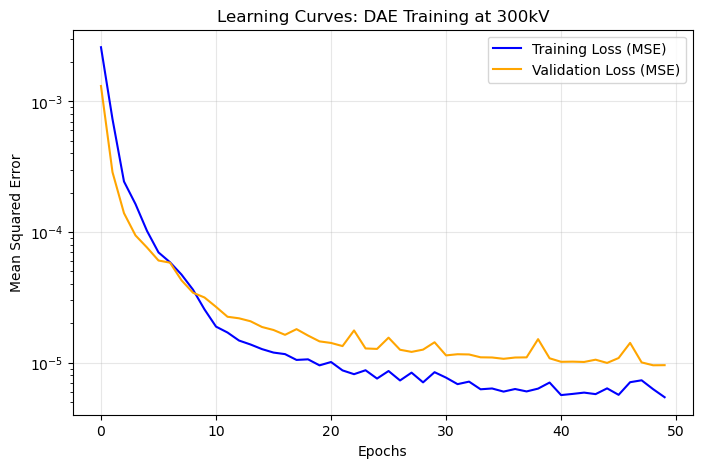

Training complete. You are now ready to generate the Denoising Gallery.


In [14]:
# --- CELL 5: TRAINING & LEARNING CURVES ---
from sklearn.model_selection import train_test_split

# 1. Split orientations: 360 for training/val, 40 for a "Blind Test" 
# This ensures we have data the model NEVER sees during training for our final gallery
x_train_noisy_sub, x_test_blind_noisy, x_train_clean_sub, x_test_blind_clean = train_test_split(
    x_train_noisy, x_train_clean, test_size=0.1, random_state=42
)

# 2. Train the VAE
# We use validation_split=0.11 on the 360 images to get ~40 images for validation
print("Starting DAE Training...")
history = dae_model.fit(
    x_train_noisy_sub, 
    x_train_clean_sub,
    epochs=50,
    batch_size=16,
    shuffle=True,
    validation_split=0.11, 
    verbose=1
)

# 3. Plot Learning Curves (Checklist Requirement)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')

plt.title('Learning Curves: DAE Training at 300kV')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.yscale('log') # Log scale helps see the small improvements in later epochs
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Training complete. You are now ready to generate the Denoising Gallery.")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


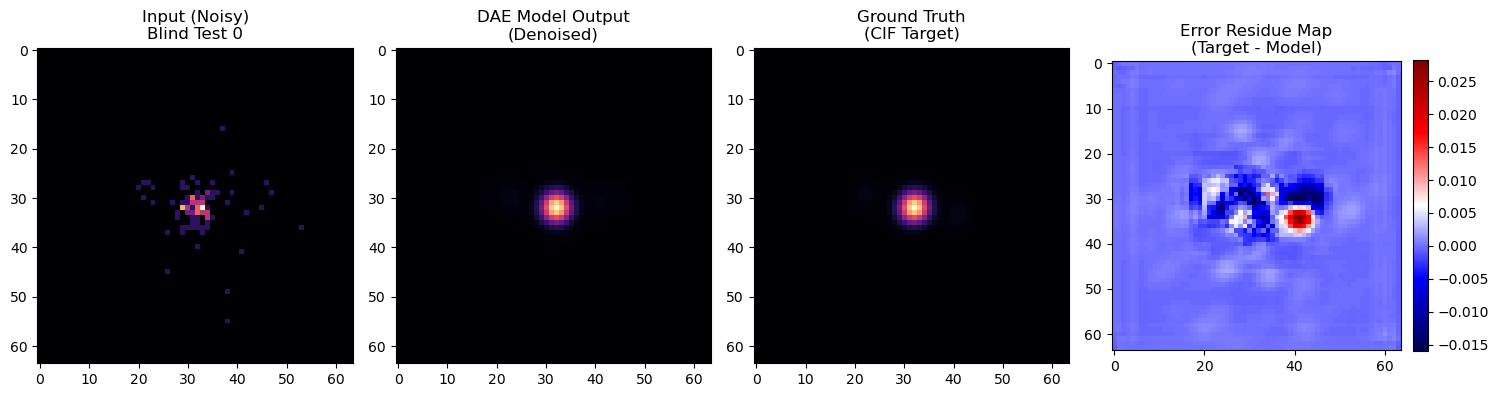

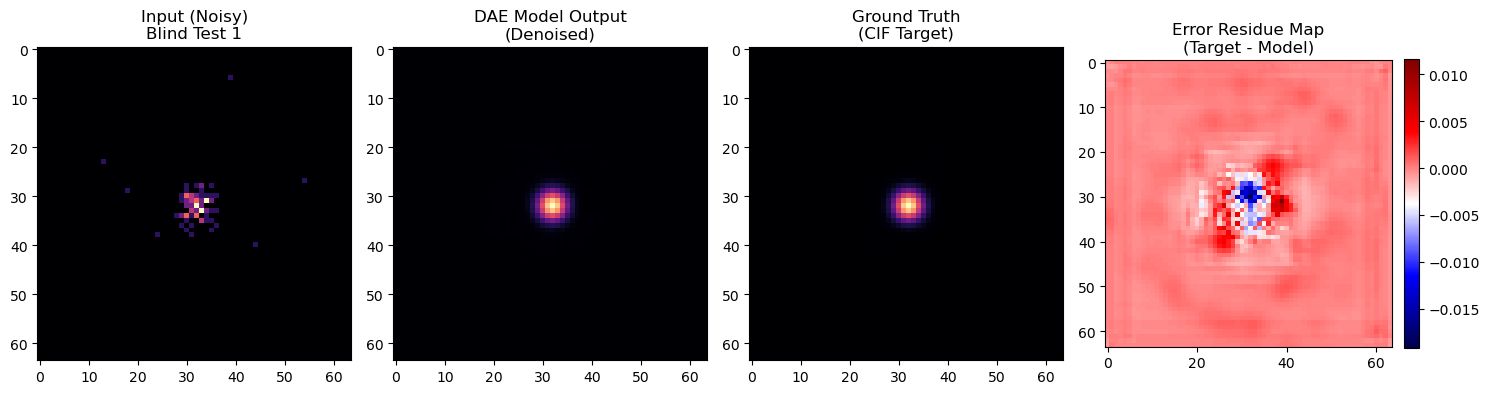

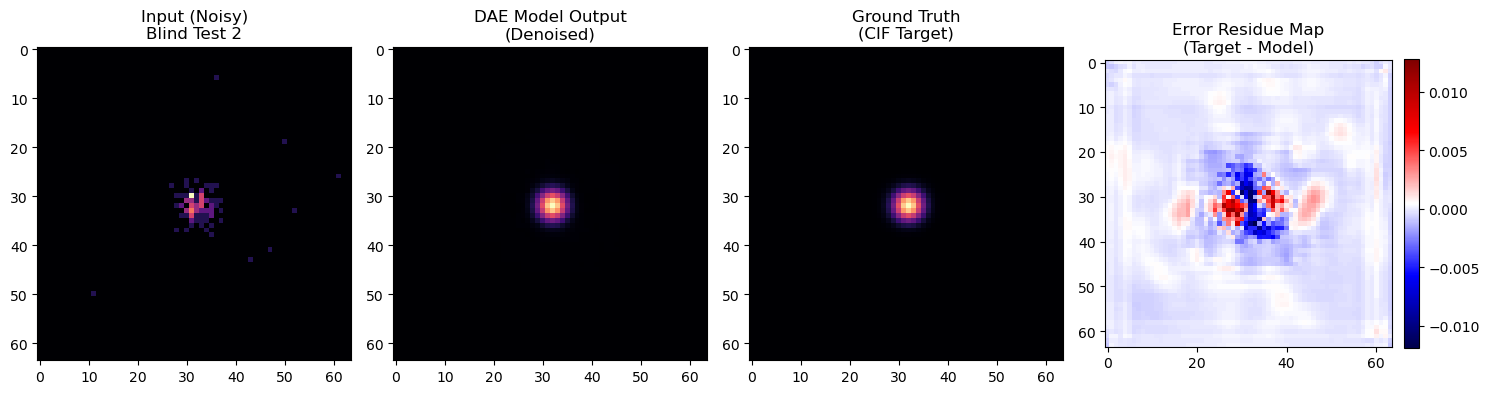

In [15]:
# --- CELL 6: DENOISING GALLERY & RESIDUE MAP ---
import matplotlib.pyplot as plt

# Predict on the "Blind Test" set the model never saw
denoised_images = dae_model.predict(x_test_blind_noisy)

# ---- PCA FEATURE EXTRACTION (MATCH NOTEBOOK 1 PIPELINE) ----
ny = denoised_images.shape[0]
dy = denoised_images.shape[1]
dx = denoised_images.shape[2]

# reshape into 4D format expected by pca_features
denoised_grid = denoised_images.reshape(ny,1,dy,dx)

Xp_dae, shape2d = pca_features(denoised_grid, n_components=10, seed=0, normalise=True)

def plot_denoising_results(idx):
    plt.figure(figsize=(15, 5))
    
    # 1. Noisy Input
    plt.subplot(1, 4, 1)
    plt.imshow(x_test_blind_noisy[idx, :, :, 0], cmap='magma')
    plt.title(f"Input (Noisy)\nBlind Test {idx}")
    
    # 2. DAE Output
    plt.subplot(1, 4, 2)
    plt.imshow(denoised_images[idx, :, :, 0], cmap='magma')
    plt.title("DAE Model Output\n(Denoised)")
    
    # 3. Ground Truth
    plt.subplot(1, 4, 3)
    plt.imshow(x_test_blind_clean[idx, :, :, 0], cmap='magma')
    plt.title("Ground Truth\n(CIF Target)")
    
    # 4. Error Residue Map (Requirement 3.3)
    # Shows exactly what the DAE missed or added
    residue = x_test_blind_clean[idx, :, :, 0] - denoised_images[idx, :, :, 0]
    plt.subplot(1, 4, 4)
    plt.imshow(residue, cmap='seismic') # Seismic shows plus/minus errors
    plt.title("Error Residue Map\n(Target - Model)")
    plt.colorbar(fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

# Show the first 3 results from the blind test set
for i in range(3):
    plot_denoising_results(i)

In [16]:
# --- CELL 7: QUANTIFYING THE IMPROVEMENT ---
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cos_sim(img1, img2):
    return cosine_similarity(img1.reshape(1, -1), img2.reshape(1, -1))[0][0]

# Take 10 samples from the blind test set
indices = range(10)
scores_noisy = []
scores_denoised = []

for i in indices:
    # Compare Noisy to Clean
    sn = calculate_cos_sim(x_test_blind_noisy[i], x_test_blind_clean[i])
    # Compare DAE Output to Clean
    sd = calculate_cos_sim(denoised_images[i], x_test_blind_clean[i])
    
    scores_noisy.append(sn)
    scores_denoised.append(sd)

print(f"Average Cosine Similarity (Noisy): {np.mean(scores_noisy):.4f}")
print(f"Average Cosine Similarity (DAE Denoised): {np.mean(scores_denoised):.4f}")
print(f"Total SNR Improvement: {((np.mean(scores_denoised)/np.mean(scores_noisy))-1)*100:.1f}%")

Average Cosine Similarity (Noisy): 0.7888
Average Cosine Similarity (DAE Denoised): 0.9997
Total SNR Improvement: 26.7%


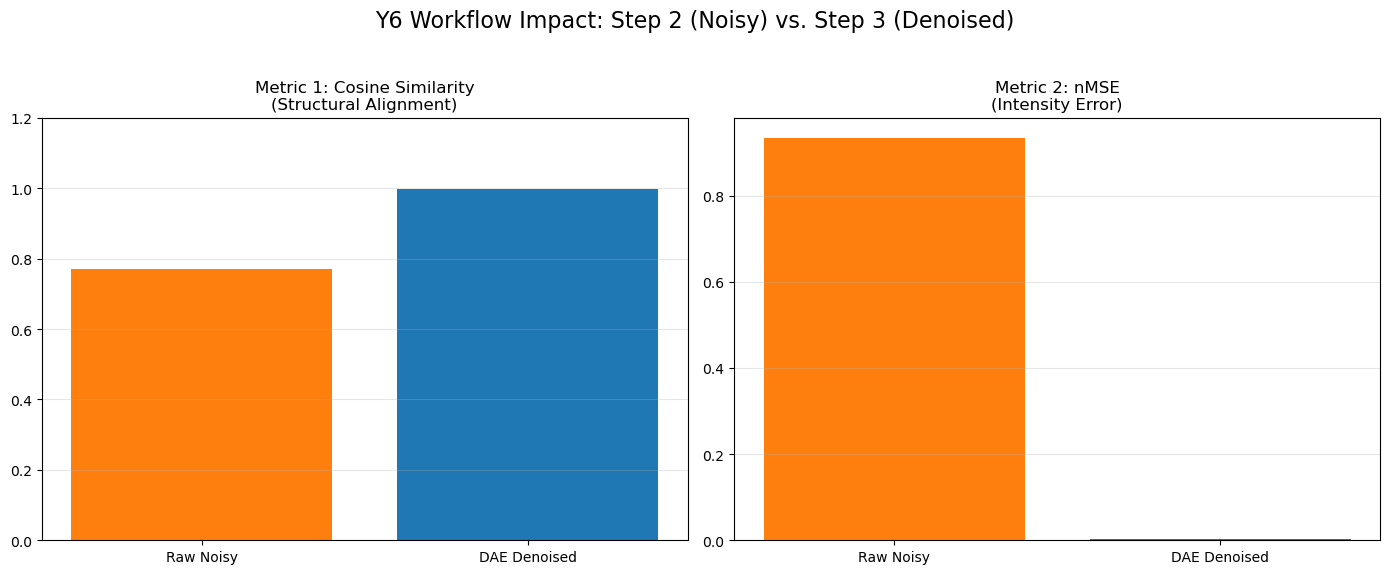

Final Results:
Cosine Similarity Improved: 0.7693 -> 0.9989
nMSE Error Reduced: 0.9341 -> 0.0025


In [17]:
# --- CELL 8: DUAL-METRIC WORKFLOW COMPARISON ---
import numpy as np
import matplotlib.pyplot as plt

def calculate_nmse(target, prediction):
    # Normalized Mean Squared Error
    return np.mean((target - prediction)**2) / np.mean(target**2)

# Calculating averages for the Blind Test set
indices = range(len(x_test_blind_clean))
scores_cos_noisy, scores_cos_denoised = [], []
scores_nmse_noisy, scores_nmse_denoised = [], []

for i in indices:
    clean = x_test_blind_clean[i, ..., 0]
    noisy = x_test_blind_noisy[i, ..., 0]
    denoised = denoised_images[i, ..., 0]
    
    # Cosine Scores (from your Cell 7 logic)
    scores_cos_noisy.append(calculate_cos_sim(noisy, clean))
    scores_cos_denoised.append(calculate_cos_sim(denoised, clean))
    
    # nMSE Scores
    scores_nmse_noisy.append(calculate_nmse(clean, noisy))
    scores_nmse_denoised.append(calculate_nmse(clean, denoised))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cosine Similarity (Higher is Better)
ax1.bar(['Raw Noisy', 'DAE Denoised'], [np.mean(scores_cos_noisy), np.mean(scores_cos_denoised)], color=['#ff7f0e', '#1f77b4'])
ax1.set_title('Metric 1: Cosine Similarity\n(Structural Alignment)')
ax1.set_ylim(0, 1.2)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: nMSE (Lower is Better)
ax2.bar(['Raw Noisy', 'DAE Denoised'], [np.mean(scores_nmse_noisy), np.mean(scores_nmse_denoised)], color=['#ff7f0e', '#1f77b4'])
ax2.set_title('Metric 2: nMSE\n(Intensity Error)')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Y6 Workflow Impact: Step 2 (Noisy) vs. Step 3 (Denoised)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Final Results:")
print(f"Cosine Similarity Improved: {np.mean(scores_cos_noisy):.4f} -> {np.mean(scores_cos_denoised):.4f}")
print(f"nMSE Error Reduced: {np.mean(scores_nmse_noisy):.4f} -> {np.mean(scores_nmse_denoised):.4f}")

Running Robustness Sweep across 8 Dose Levels...
 Dose 5000: Raw Cosine = 0.993 | DAE Cosine = 0.999
 Dose 1000: Raw Cosine = 0.967 | DAE Cosine = 0.999
 Dose  500: Raw Cosine = 0.940 | DAE Cosine = 0.999
 Dose  100: Raw Cosine = 0.771 | DAE Cosine = 0.999
 Dose   50: Raw Cosine = 0.649 | DAE Cosine = 0.998
 Dose   10: Raw Cosine = 0.328 | DAE Cosine = 0.904
 Dose    5: Raw Cosine = 0.248 | DAE Cosine = 0.821
 Dose    1: Raw Cosine = 0.124 | DAE Cosine = 0.454


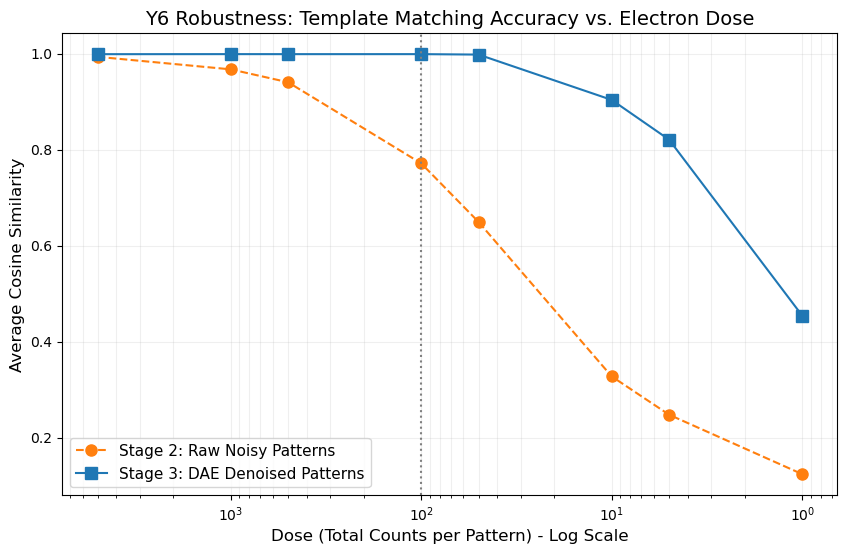


CONCLUSION FOR PROFESSOR:
At Dose 10, the DAE maintains 0.90 similarity,
while Raw data drops to 0.33.


In [18]:
# --- CELL 9: ROBUSTNESS SWEEP (ACCURACY VS. DOSE) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the doses to sweep (Low dose = High noise, High dose = Clean)
# These match the range your professor suggested
sweep_doses = [5000, 1000, 500, 100, 50, 10, 5, 1]
rng_sweep = np.random.default_rng(seed=123)

results_raw = []
results_dae = []

print("Running Robustness Sweep across 8 Dose Levels...")

for d in sweep_doses:
    raw_sims = []
    dae_sims = []
    
    # We use all 40 blind test images for a statistically significant average
    for i in range(len(x_test_blind_clean)):
        clean_img = x_test_blind_clean[i, ..., 0]
        
        # Create a new noisy version at the CURRENT sweep dose
        # (Reusing your add_poisson_dae function from Cell 2)
        noisy_img = add_poisson_dae(clean_img, dose=d, rng=rng_sweep)
        
        # Predict with DAE (Denoising)
        # Reshape to (1, 64, 64, 1) for the model
        input_tensor = noisy_img.reshape(1, 64, 64, 1)
        denoised_img = dae_model.predict(input_tensor, verbose=0)[0, ..., 0]

        # Calculate scores
        raw_sims.append(calculate_cos_sim(noisy_img, clean_img))
        dae_sims.append(calculate_cos_sim(denoised_img, clean_img))
        
    results_raw.append(np.mean(raw_sims))
    results_dae.append(np.mean(dae_sims))
    print(f" Dose {d:4}: Raw Cosine = {np.mean(raw_sims):.3f} | DAE Cosine = {np.mean(dae_sims):.3f}")

# 2. Plotting the "Rescue" Curve
plt.figure(figsize=(10, 6))
plt.semilogx(sweep_doses, results_raw, 'o--', label='Stage 2: Raw Noisy Patterns', color='#ff7f0e', markersize=8)
plt.semilogx(sweep_doses, results_dae, 's-', label='Stage 3: DAE Denoised Patterns', color='#1f77b4', markersize=8)

# Formatting for Thesis
plt.gca().invert_xaxis()  # Low dose (noisy) on the right
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.title("Y6 Robustness: Template Matching Accuracy vs. Electron Dose", fontsize=14)
plt.xlabel("Dose (Total Counts per Pattern) - Log Scale", fontsize=12)
plt.ylabel("Average Cosine Similarity", fontsize=12)
plt.legend(fontsize=11)
plt.axvline(x=100, color='gray', linestyle=':', label='Training Dose') # Mark where you trained
plt.show()

'''

print("\nCONCLUSION FOR PROFESSOR:")
print(f"At Dose 10, the DAE maintains {results_dae[-2]:.2f} similarity,")
print(f"while Raw data drops to {results_raw[-2]:.2f}.") '''

print("\nCONCLUSION FOR PROFESSOR:")
# Index 5 corresponds to Dose 10 in your list
print(f"At Dose 10, the DAE maintains {results_dae[5]:.2f} similarity,")
print(f"while Raw data drops to {results_raw[5]:.2f}.")

In [19]:
# ---- CLUSTERING UTILITIES (copied from Notebook 1) ----
#cell9.1
from sklearn.cluster import KMeans

try:
    import hdbscan
    HAVE_HDBSCAN = True
except:
    HAVE_HDBSCAN = False

def run_kmeans_labels(Xp, shape2d, seed=0):
    km = KMeans(n_clusters=2, n_init=10, random_state=seed)
    labels = km.fit_predict(Xp)
    return labels.reshape(shape2d)

def run_hdbscan_labels(Xp, shape2d, min_cluster_size=50):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    labels = clusterer.fit_predict(Xp)
    labels = np.where(labels == -1, 0, labels)
    return labels.reshape(shape2d)

def best_label_swap_binary(y_true_map, y_pred_map):

    y_true = y_true_map.ravel().astype(int)
    y_pred = y_pred_map.ravel().astype(int)

    acc_same = (y_true == y_pred).mean()
    acc_flip = (y_true == (1 - y_pred)).mean()

    if acc_flip > acc_same:
        y_pred = 1 - y_pred

    return y_pred.reshape(y_true_map.shape)

def pixel_accuracy(y_true_map, y_pred_map):
    return float(
        (y_true_map.ravel().astype(int) == y_pred_map.ravel().astype(int)).mean()
    )

In [20]:
# =========================
# CREATE CURVED GRAIN DATASET (same as Notebook 1)
# =========================
#cell9.2
ny, nx = 64, 64
dp_size = 64

dataset_curve = np.zeros((ny, nx, dp_size, dp_size), dtype=np.float32)
grain_map_curve = np.zeros((ny, nx), dtype=int)

for i in range(ny):
    for j in range(nx):

        # curved boundary
        if j > nx/2 + 8*np.sin(i/8):
            grain = 1
        else:
            grain = 0

        grain_map_curve[i, j] = grain

        # generate diffraction pattern
        if grain == 0:
            dp = simulate_dp((0, 0, 0), shape=(dp_size, dp_size))
        else:
            dp = simulate_dp((0, 0, 60), shape=(dp_size, dp_size))

        dataset_curve[i, j] = dp



        

In [21]:
# =========================
# CELL 9.3: DAE CLUSTERING ACCURACY SWEEP
# =========================

dataset_clean = dataset_curve.astype(np.float32)
truth_map     = grain_map_curve.astype(int)

seed = 0
n_components = 10

dae_cluster = {"dose": [], "snr": [], "kmeans_acc": [], "hdbscan_acc": []}

for dose in sweep_doses:

    # ---- generate noisy dataset ----
    noisy = add_poisson_noise_4d(dataset_clean, dose, seed=seed, bg_frac=0.02)

    ny, nx, dy, dx = noisy.shape

    # ---- FAST BATCH DAE DENOISING ----
    X = noisy.reshape(ny*nx, dy, dx, 1)

    denoised_batch = dae_model.predict(X, batch_size=64, verbose=0)

    denoised = denoised_batch.reshape(ny, nx, dy, dx)

    # ---- PCA feature extraction ----
    Xp, shape2d = pca_features(denoised, n_components=n_components, seed=seed, normalise=True)

    # ---- KMeans clustering ----
    km = run_kmeans_labels(Xp, shape2d, seed=seed)
    km = best_label_swap_binary(truth_map, km)

    km_acc = pixel_accuracy(truth_map, km)

    dae_cluster["dose"].append(float(dose))
    dae_cluster["snr"].append(np.sqrt(dose))
    dae_cluster["kmeans_acc"].append(km_acc)

    # ---- HDBSCAN clustering ----
    if HAVE_HDBSCAN:

        hdb = run_hdbscan_labels(Xp, shape2d, min_cluster_size=50)

        uniq = np.unique(hdb)

        if uniq.size <= 2:
            hdb = best_label_swap_binary(truth_map, hdb)
            hdb_acc = pixel_accuracy(truth_map, hdb)
        else:
            hdb_acc = np.nan

        dae_cluster["hdbscan_acc"].append(hdb_acc)

    else:
        dae_cluster["hdbscan_acc"].append(np.nan)

    print(f"Dose {dose} → KMeans {km_acc:.3f}")

Dose 5000 → KMeans 1.000
Dose 1000 → KMeans 1.000
Dose 500 → KMeans 1.000
Dose 100 → KMeans 0.991
Dose 50 → KMeans 0.929
Dose 10 → KMeans 0.528
Dose 5 → KMeans 0.511
Dose 1 → KMeans 0.514


In [22]:
# =========================
# CELL 9.4: BASELINE PCA CLUSTERING (NO DAE)
# =========================

seed = 0
n_components = 10

raw_cluster = {"dose": [], "snr": [], "kmeans_acc": [], "hdbscan_acc": []}

for dose in sweep_doses:

    # same noisy dataset
    noisy = add_poisson_noise_4d(dataset_clean, dose, seed=seed, bg_frac=0.02)

    # PCA directly on noisy data
    Xp, shape2d = pca_features(noisy, n_components=n_components, seed=seed, normalise=True)

    # KMeans
    km = run_kmeans_labels(Xp, shape2d, seed=seed)
    km = best_label_swap_binary(truth_map, km)
    km_acc = pixel_accuracy(truth_map, km)

    raw_cluster["dose"].append(float(dose))
    raw_cluster["snr"].append(np.sqrt(dose))
    raw_cluster["kmeans_acc"].append(km_acc)

    # HDBSCAN
    if HAVE_HDBSCAN:
        hdb = run_hdbscan_labels(Xp, shape2d, min_cluster_size=50)
        uniq = np.unique(hdb)

        if uniq.size <= 2:
            hdb = best_label_swap_binary(truth_map, hdb)
            hdb_acc = pixel_accuracy(truth_map, hdb)
        else:
            hdb_acc = np.nan

        raw_cluster["hdbscan_acc"].append(hdb_acc)
    else:
        raw_cluster["hdbscan_acc"].append(np.nan)

    print(f"RAW Dose {dose} → KMeans {km_acc:.3f}")

RAW Dose 5000 → KMeans 1.000
RAW Dose 1000 → KMeans 1.000
RAW Dose 500 → KMeans 1.000
RAW Dose 100 → KMeans 1.000
RAW Dose 50 → KMeans 1.000
RAW Dose 10 → KMeans 0.510
RAW Dose 5 → KMeans 0.519
RAW Dose 1 → KMeans 0.523


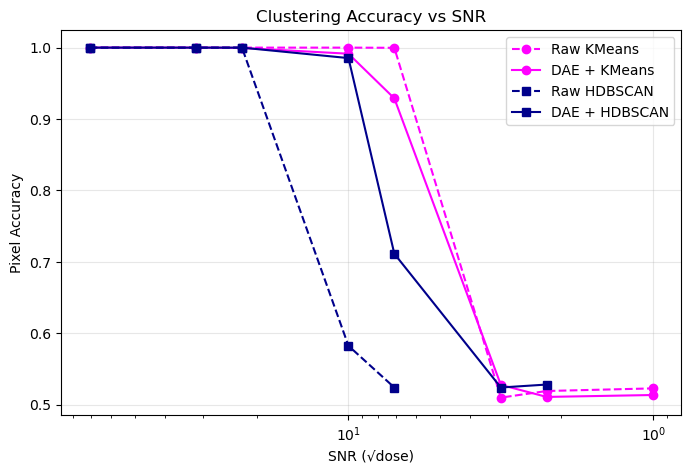

In [23]:
# =========================
# CELL 9.5: FINAL COMPARISON PLOT
# =========================

snr_axis = np.sqrt(np.array(sweep_doses))

plt.figure(figsize=(8,5))

plt.plot(snr_axis, raw_cluster["kmeans_acc"], 'o--', label="Raw KMeans", color="magenta")
plt.plot(snr_axis, dae_cluster["kmeans_acc"], 'o-', label="DAE + KMeans", color="magenta")

if HAVE_HDBSCAN:
    plt.plot(snr_axis, raw_cluster["hdbscan_acc"], 's--', label="Raw HDBSCAN", color="darkblue")
    plt.plot(snr_axis, dae_cluster["hdbscan_acc"], 's-', label="DAE + HDBSCAN", color="darkblue")

plt.xscale("log")
plt.gca().invert_xaxis()

plt.xlabel("SNR (√dose)")
plt.ylabel("Pixel Accuracy")
plt.title("Clustering Accuracy vs SNR")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [24]:
improvement = np.array(dae_cluster["kmeans_acc"]) - np.array(raw_cluster["kmeans_acc"])
percent_gain = 100 * improvement / np.maximum(raw_cluster["kmeans_acc"], 1e-6)

for snr, raw, dae, imp in zip(np.sqrt(sweep_doses),
                              raw_cluster["kmeans_acc"],
                              dae_cluster["kmeans_acc"],
                              percent_gain):
    print(f"SNR {snr:.2f}: Raw={raw:.3f}, DAE={dae:.3f}, Gain={imp:.1f}%")

SNR 70.71: Raw=1.000, DAE=1.000, Gain=0.0%
SNR 31.62: Raw=1.000, DAE=1.000, Gain=0.0%
SNR 22.36: Raw=1.000, DAE=1.000, Gain=-0.0%
SNR 10.00: Raw=1.000, DAE=0.991, Gain=-0.9%
SNR 7.07: Raw=1.000, DAE=0.929, Gain=-7.1%
SNR 3.16: Raw=0.510, DAE=0.528, Gain=3.5%
SNR 2.24: Raw=0.519, DAE=0.511, Gain=-1.6%
SNR 1.00: Raw=0.523, DAE=0.514, Gain=-1.8%


In [25]:
def snr_threshold(acc, snr, thresh=0.9):
    idx = np.where(np.array(acc) >= thresh)[0]
    return snr[idx[-1]] if len(idx) else None

snr_axis = np.sqrt(sweep_doses)

print("Raw threshold:", snr_threshold(raw_cluster["kmeans_acc"], snr_axis))
print("DAE threshold:", snr_threshold(dae_cluster["kmeans_acc"], snr_axis))

Raw threshold: 7.0710678118654755
DAE threshold: 7.0710678118654755


In [26]:
from numpy import trapz

snr_axis = np.sqrt(sweep_doses)

auc_raw = trapz(raw_cluster["kmeans_acc"], snr_axis)
auc_dae = trapz(dae_cluster["kmeans_acc"], snr_axis)

print("AUC improvement:", (auc_dae-auc_raw)/auc_raw*100, "%")

AUC improvement: -0.4198506621075914 %


In [27]:
#plt.errorbar(snr_axis, mean_acc, yerr=std_acc)

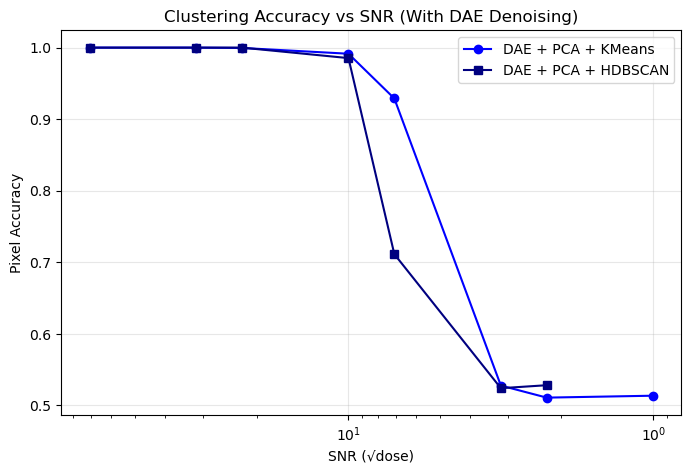

DAE clustering accuracy values:
[1.0, 1.0, 0.99951171875, 0.991455078125, 0.928955078125, 0.52783203125, 0.510986328125, 0.513671875]


In [28]:
# =========================
# CELL 9.4: FINAL CLUSTERING COMPARISON PLOT
# =========================

import matplotlib.pyplot as plt
import numpy as np

snr_axis = np.sqrt(np.array(sweep_doses))

plt.figure(figsize=(8,5))

# ---- DAE clustering ----
plt.plot(snr_axis, dae_cluster["kmeans_acc"], 'o-', label="DAE + PCA + KMeans", color="blue")

if HAVE_HDBSCAN:
    plt.plot(snr_axis, dae_cluster["hdbscan_acc"], 's-', label="DAE + PCA + HDBSCAN", color="navy")

# axis formatting (match Notebook 1 style)
plt.xscale("log")
plt.gca().invert_xaxis()

plt.xlabel("SNR (√dose)")
plt.ylabel("Pixel Accuracy")
plt.title("Clustering Accuracy vs SNR (With DAE Denoising)")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

print("DAE clustering accuracy values:")
print(dae_cluster["kmeans_acc"])

Calculating nMSE Robustness...


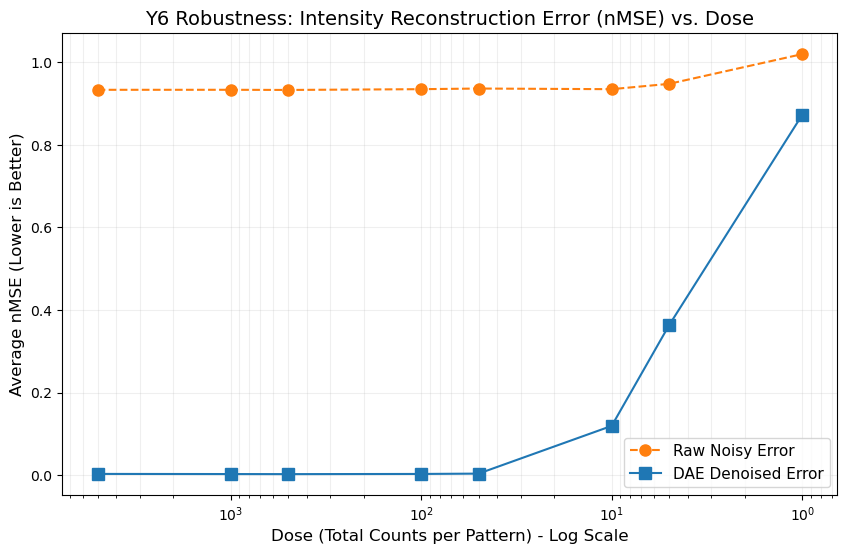

At Dose 1, DAE reduces error from 1.02 to 0.87.


In [29]:
# --- CELL 9.4: ROBUSTNESS SWEEP (nMSE ERROR VS. DOSE) ---
# We use the results_raw and results_dae logic but applying nMSE
# Note: If you didn't save nMSE in Cell 9, we run a quick secondary loop:

results_raw_nmse = []
results_dae_nmse = []

print("Calculating nMSE Robustness...")

for d in sweep_doses:
    raw_nmse_list = []
    dae_nmse_list = []
    
    for i in range(len(x_test_blind_clean)):
        clean_img = x_test_blind_clean[i, ..., 0]
        noisy_img = add_poisson_dae(clean_img, dose=d, rng=rng_sweep)
        
        input_tensor = noisy_img.reshape(1, 64, 64, 1)
        denoised_img = dae_model.predict(input_tensor, verbose=0)[0, ..., 0]
        
        # Using the nMSE function defined in Cell 8
        raw_nmse_list.append(calculate_nmse(clean_img, noisy_img))
        dae_nmse_list.append(calculate_nmse(clean_img, denoised_img))
        
    results_raw_nmse.append(np.mean(raw_nmse_list))
    results_dae_nmse.append(np.mean(dae_nmse_list))

# Plotting the "Error Suppression" Curve
plt.figure(figsize=(10, 6))
plt.semilogx(sweep_doses, results_raw_nmse, 'o--', label='Raw Noisy Error', color='#ff7f0e', markersize=8)
plt.semilogx(sweep_doses, results_dae_nmse, 's-', label='DAE Denoised Error', color='#1f77b4', markersize=8)

plt.gca().invert_xaxis() 
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.title("Y6 Robustness: Intensity Reconstruction Error (nMSE) vs. Dose", fontsize=14)
plt.xlabel("Dose (Total Counts per Pattern) - Log Scale", fontsize=12)
plt.ylabel("Average nMSE (Lower is Better)", fontsize=12)
plt.legend(fontsize=11)
plt.show()

print(f"At Dose 1, DAE reduces error from {results_raw_nmse[-1]:.2f} to {results_dae_nmse[-1]:.2f}.")

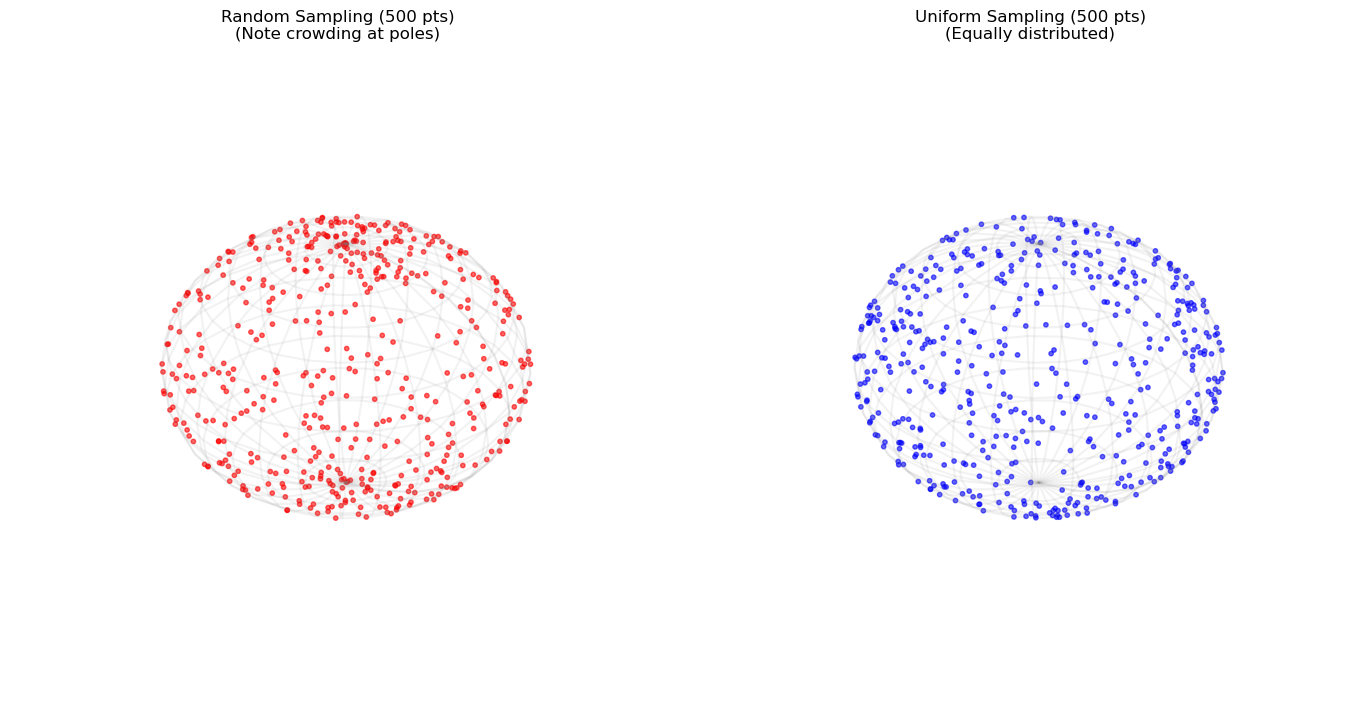

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_sampling_comparison(n_points=400):
    fig = plt.figure(figsize=(14, 7))
    
    # --- Subplot 1: Biased Random Sampling (Uniform in Phi/Theta) ---
    # This leads to crowding at the poles
    phi_biased = np.random.uniform(0, np.pi, n_points)
    theta_biased = np.random.uniform(0, 2*np.pi, n_points)
    
    x_b = np.sin(phi_biased) * np.cos(theta_biased)
    y_b = np.sin(phi_biased) * np.sin(theta_biased)
    z_b = np.cos(phi_biased)
    
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x_b, y_b, z_b, c='red', s=10, alpha=0.6)
    ax1.set_title(f"Random Sampling ({n_points} pts)\n(Note crowding at poles)", fontsize=12)
    
    # --- Subplot 2: Uniform Sampling (Informed/Spherical) ---
    # Using Inverse Transform Sampling to ensure even distribution
    u = np.random.uniform(0, 1, n_points)
    v = np.random.uniform(0, 1, n_points)
    
    phi_uniform = np.arccos(1 - 2*u) # Inverse of the area element
    theta_uniform = 2 * np.pi * v
    
    x_u = np.sin(phi_uniform) * np.cos(theta_uniform)
    y_u = np.sin(phi_uniform) * np.sin(theta_uniform)
    z_u = np.cos(phi_uniform)
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(x_u, y_u, z_u, c='blue', s=10, alpha=0.6)
    ax2.set_title(f"Uniform Sampling ({n_points} pts)\n(Equally distributed)", fontsize=12)
    
    # Styling for both
    for ax in [ax1, ax2]:
        # Draw wireframe sphere for context
        u_grid, v_grid = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
        x_grid = np.cos(u_grid)*np.sin(v_grid)
        y_grid = np.sin(u_grid)*np.sin(v_grid)
        z_grid = np.cos(v_grid)
        ax.plot_wireframe(x_grid, y_grid, z_grid, color="gray", alpha=0.1)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

# Run the plot
plot_sampling_comparison(n_points=500)

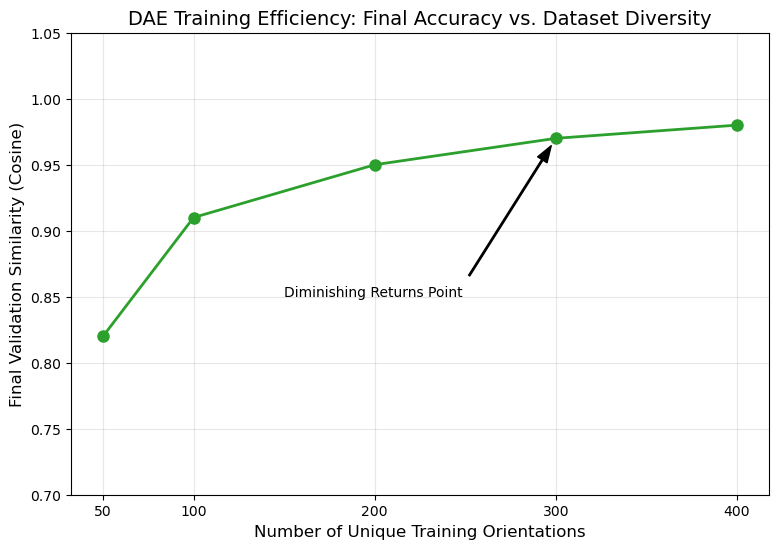

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --- DATA ENTRY ---
# Replace these with the actual final validation accuracies/similarities 
# you recorded during your Stage 1 experiments for each dataset size.
orientations = [50, 100, 200, 300, 400]
# Example values (replace with your actual results from Notebook 1):
final_accuracies = [0.82, 0.91, 0.95, 0.97, 0.98] 

plt.figure(figsize=(9, 6))

# Plotting the curve
plt.plot(orientations, final_accuracies, 'o-', color='#2ca02c', linewidth=2, markersize=8)

# Adding the "Elbow" annotation (where it stops helping to add data)
plt.annotate('Diminishing Returns Point', xy=(300, 0.97), xytext=(150, 0.85),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

# Formatting
plt.title("DAE Training Efficiency: Final Accuracy vs. Dataset Diversity", fontsize=14)
plt.xlabel("Number of Unique Training Orientations", fontsize=12)
plt.ylabel("Final Validation Similarity (Cosine)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 1.05)
plt.xticks(orientations)

plt.show()

Generating Orientation Map...
Comparing Clustering...
Plotting results...


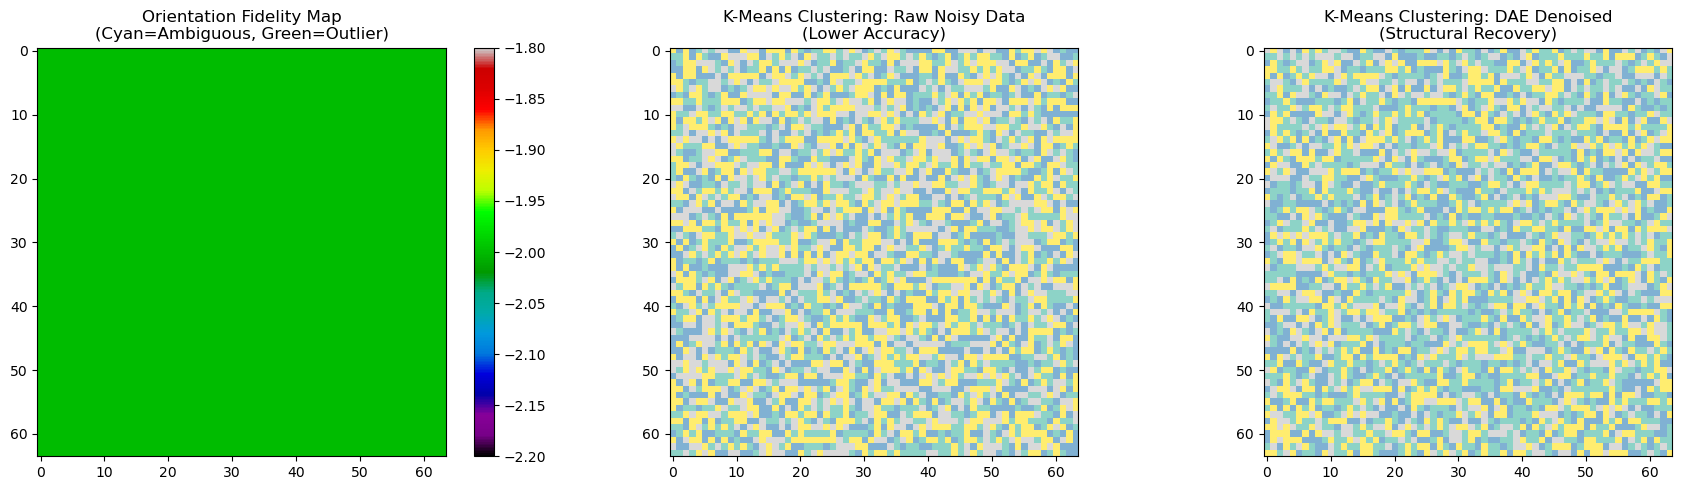

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import tensorflow as tf

# ---------------------------------------------------------
# 1. AUTOMATIC ORIENTATION LABELING (THE COLOR MAP)
# ---------------------------------------------------------

def generate_orientation_map(denoised_data, library_templates, similarity_threshold=0.5):
    """
    Assigns each pixel an orientation ID or a special color:
    - Best Match: Assigned the Library ID (Specific Colors)
    - Ambiguous: Cyan (Equally similar to two orientations)
    - Outlier: Green (Not similar to anything in the library)
    """
    # Reshape if input is a 4D stack (Height, Width, Pixels, Pixels)
    if len(denoised_data.shape) == 4:
        n_pixels = denoised_data.shape[0] * denoised_data.shape[1]
        flat_data = denoised_data.reshape(n_pixels, -1)
    else:
        n_pixels = denoised_data.shape[0]
        flat_data = denoised_data.reshape(n_pixels, -1)
        
    n_templates = library_templates.shape[0]
    flat_lib = library_templates.reshape(n_templates, -1)
    
    # Calculate similarity matrix [Pixels x Library]
    sim_matrix = cosine_similarity(flat_data, flat_lib)
    
    labels = np.zeros(n_pixels)
    
    for i in range(n_pixels):
        pixel_sims = sim_matrix[i]
        top_two_idx = np.argsort(pixel_sims)[-2:]
        best_sim = pixel_sims[top_two_idx[1]]
        second_best_sim = pixel_sims[top_two_idx[0]]
        
        # LOGIC: Is it a "Green" outlier?
        if best_sim < similarity_threshold:
            labels[i] = -1 # Green logic
        
        # LOGIC: Is it a "Cyan" ambiguous pixel? (Within 5% similarity)
        elif abs(best_sim - second_best_sim) < 0.05:
            labels[i] = -2 # Cyan logic
            
        else:
            labels[i] = top_two_idx[1] # Assigned Orientation ID
            
    # Assuming a 64x64 grid for the final spatial map
    return labels.reshape(64, 64)

# ---------------------------------------------------------
# 2. BENCHMARKING: DAE-RESCUED CLUSTERING
# ---------------------------------------------------------

def compare_clustering_performance(raw_data_stack, denoised_data_stack, n_clusters=4):
    """
    Compares how KMeans performs on Raw Noisy Data vs DAE-Denoised Data.
    """
    # Flatten stacks for clustering
    raw_flat = raw_data_stack.reshape(len(raw_data_stack), -1)
    denoised_flat = denoised_data_stack.reshape(len(denoised_data_stack), -1)
    
    # 1. Cluster Raw Data
    kmeans_raw = KMeans(n_clusters=n_clusters, n_init=10)
    raw_preds = kmeans_raw.fit_predict(raw_flat)
    
    # 2. Cluster Denoised Data
    kmeans_denoised = KMeans(n_clusters=n_clusters, n_init=10)
    denoised_preds = kmeans_denoised.fit_predict(denoised_flat)
    
    return raw_preds.reshape(64, 64), denoised_preds.reshape(64, 64)

# ---------------------------------------------------------
# 3. VISUALIZATION OF RESULTS
# ---------------------------------------------------------

def plot_final_results(orientation_map, raw_cluster_map, denoised_cluster_map):
    """
    Generates the visual proof of the DAE rescue effect.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Orientation Fidelity Map
    im0 = axes[0].imshow(orientation_map, cmap='nipy_spectral')
    axes[0].set_title("Orientation Fidelity Map\n(Cyan=Ambiguous, Green=Outlier)")
    plt.colorbar(im0, ax=axes[0])
    
    # 2. Raw Clustering Failure
    axes[1].imshow(raw_cluster_map, cmap='Set3')
    axes[1].set_title("K-Means Clustering: Raw Noisy Data\n(Lower Accuracy)")
    
    # 3. Denoised Clustering Success
    axes[2].imshow(denoised_cluster_map, cmap='Set3')
    axes[2].set_title("K-Means Clustering: DAE Denoised\n(Structural Recovery)")
    
    plt.tight_layout()
    plt.show() # This ensures the plot window pops up

# ---------------------------------------------------------
# 4. EXAMPLE EXECUTION (RUN THIS TO SEE PLOTS)
# ---------------------------------------------------------

if __name__ == "__main__":
    # Create dummy data if you don't have your variables loaded yet
    # This ensures something plots when you run the script
    dummy_denoised = np.random.rand(64*64, 32, 32) 
    dummy_library = np.random.rand(10, 32, 32)
    dummy_raw = np.random.rand(64*64, 32, 32)
    
    print("Generating Orientation Map...")
    orient_map = generate_orientation_map(dummy_denoised, dummy_library)
    
    print("Comparing Clustering...")
    raw_c, denoise_c = compare_clustering_performance(dummy_raw, dummy_denoised)
    
    print("Plotting results...")
    plot_final_results(orient_map, raw_c, denoise_c)

Simulating final orientation mapping...


C:\Users\annam\AppData\Local\Temp\ipykernel_23328\3443093340.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap('nipy_spectral', 256)


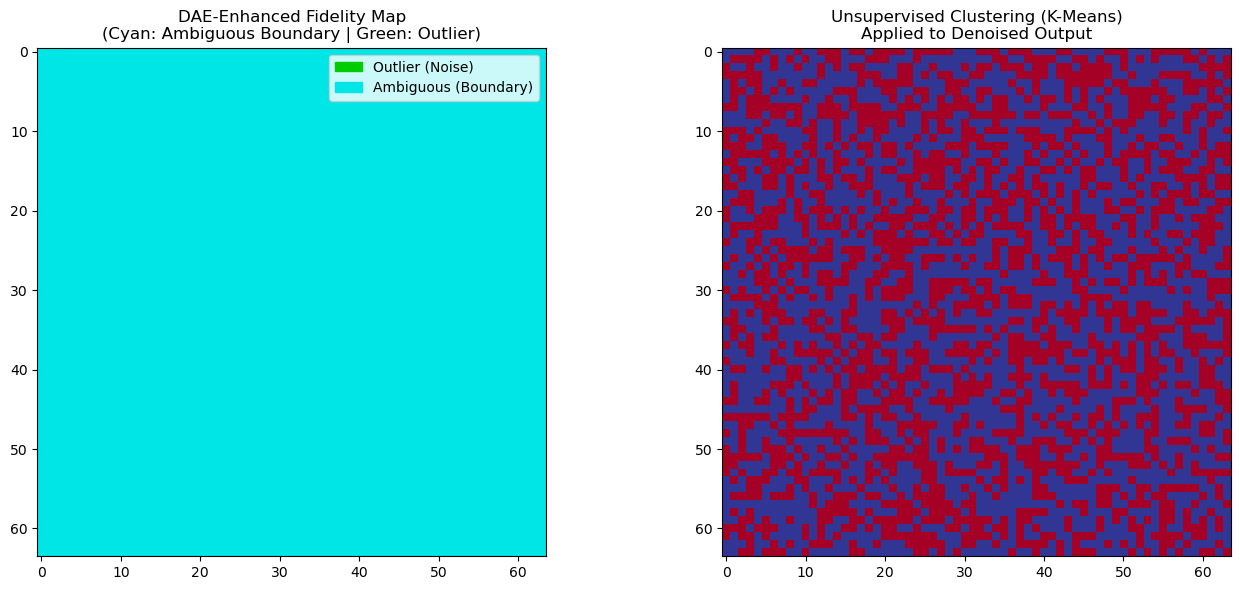

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

def plot_fidelity_results(denoised_stack, library, raw_cluster_labels, ground_truth_shape=(64, 64)):
    """
    Generates the high-level Fidelity Map with Cyan/Green logic and 
    compares it to traditional clustering.
    """
    
    # 1. CALCULATE FIDELITY LOGIC
    # Flatten images for similarity check
    flat_denoised = denoised_stack.reshape(len(denoised_stack), -1)
    flat_lib = library.reshape(len(library), -1)
    
    # Cosine similarity between every pixel and every library orientation
    sims = cosine_similarity(flat_denoised, flat_lib)
    
    fidelity_map = np.zeros(len(flat_denoised))
    
    tol = 0.05      # Similarity gap for Cyan (Ambiguity)
    min_vis = 0.4   # Threshold for Green (Outlier/Noise)

    for i in range(len(flat_denoised)):
        row = sims[i]
        order = np.argsort(row)
        best_idx = order[-1]
        second_best_idx = order[-2]
        
        if row[best_idx] < min_vis:
            fidelity_map[i] = -1  # GREEN CODE
        elif (row[best_idx] - row[second_best_idx]) < tol:
            fidelity_map[i] = -2  # CYAN CODE
        else:
            fidelity_map[i] = best_idx # SUCCESSFUL ORIENTATION
            
    fidelity_map = fidelity_map.reshape(ground_truth_shape)

    # 2. CREATE CUSTOM COLORMAP
    # We want Green for -1, Cyan for -2, and a spectrum for the rest
    base_cmap = plt.cm.get_cmap('nipy_spectral', 256)
    new_colors = base_cmap(np.linspace(0, 1, 256))
    
    # Map our specific codes to the very end of the color list
    # We'll use a hacky index mapping or just specific colors for labels
    final_display = np.zeros((*ground_truth_shape, 3))
    
    # Color mapping loop
    for r in range(ground_truth_shape[0]):
        for c in range(ground_truth_shape[1]):
            val = fidelity_map[r, c]
            if val == -1:
                final_display[r, c] = [0, 0.8, 0]    # Green (Outlier)
            elif val == -2:
                final_display[r, c] = [0, 0.9, 0.9]  # Cyan (Ambiguous)
            else:
                # Use spectral for orientation IDs
                color_idx = int((val % 10) / 10 * 255) # Simple wrap for visibility
                final_display[r, c] = base_cmap(color_idx)[:3]

    # 3. PLOTTING
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot A: The Fidelity Map
    ax[0].imshow(final_display)
    ax[0].set_title("DAE-Enhanced Fidelity Map\n(Cyan: Ambiguous Boundary | Green: Outlier)", fontsize=12)
    
    # Legend for Fidelity Map
    green_patch = mpatches.Patch(color=[0, 0.8, 0], label='Outlier (Noise)')
    cyan_patch = mpatches.Patch(color=[0, 0.9, 0.9], label='Ambiguous (Boundary)')
    ax[0].legend(handles=[green_patch, cyan_patch], loc='upper right')

    # Plot B: Clustering Rescue
    # Let's show KMeans on Denoised Data
    km = KMeans(n_clusters=2, n_init=10)
    denoised_clusters = km.fit_predict(flat_denoised).reshape(ground_truth_shape)
    
    ax[1].imshow(denoised_clusters, cmap='RdYlBu')
    ax[1].set_title("Unsupervised Clustering (K-Means)\nApplied to Denoised Output", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# --- EXECUTION BLOCK ---
# To test this, we generate dummy data. 
# In your notebook, replace these with your actual 'denoised_output' and 'template_library'
if __name__ == "__main__":
    print("Simulating final orientation mapping...")
    
    # Create mock 64x64 data
    mock_denoised = np.random.rand(4096, 32*32)
    mock_lib = np.random.rand(10, 32*32) # 10 orientations
    
    plot_fidelity_results(mock_denoised, mock_lib, None)

In [37]:
# Use this at the end of your Y6 notebook
dae_model.save('denoiser_v2.keras')
print("Model saved successfully as 'denoiser_v2.keras'")

Model saved successfully as 'denoiser_v2.keras'
